# 🎓 Times Higher Education World University Rankings — EDA

**Dataset:** 2,191 institutions · 115 countries · Times Higher Education World University Rankings

This notebook works through the full analysis: cleaning the dataset's banded ranks and string-formatted stats, examining what drives overall score, comparing the top 100 against everyone else, and profiling national higher-education systems.

Every chart and statistic here is reproducible with `python src/eda_pipeline.py`.

## 1. Setup

In [40]:
import sys
sys.path.insert(0, "../src")

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from eda_pipeline import (
    load_data, clean_data, summary_stats,
    pillar_correlations, country_summary, elite_vs_rest,
    SCORE_COLS, PRETTY,
)

sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", 40)

In [67]:
SKY_BLUE = "#87CEEB"
sns.set_theme(
    style="whitegrid",
    context="notebook"
)

plt.rcParams.update({
    "figure.figsize": (10, 6),
    "figure.dpi": 100,

    "axes.facecolor": "white",
    "figure.facecolor": "white",
    "grid.color": SKY_BLUE,
    "grid.alpha": 0.35,

    "axes.titleweight": "bold",
    "axes.titlesize": 14,

    "axes.labelsize": 11,
    "font.size": 10
})


THEME_COLORS = {
    "primary": "#87CEEB",  
    "secondary": "#8B0000",  
    "background": "#FFFFFF"
}

## 2. Load the raw data

Thirty columns, most of which are metadata. The analysis columns need work before they're usable.

In [42]:
raw = load_data("../dataset/world_university_rankings_2191.csv")
print(raw.shape)
raw.head()

(2191, 30)


,rank_order,rank,name,scores_overall,scores_overall_rank,scores_teaching,scores_teaching_rank,scores_research,scores_research_rank,scores_citations,scores_citations_rank,scores_industry_income,scores_industry_income_rank,scores_international_outlook,scores_international_outlook_rank,iid,record_type,member_level,url,nid,location,stats_number_students,stats_student_staff_ratio,stats_pc_intl_students,stats_female_male_ratio,aliases,closed,unaccredited,disabled,apply_link
0,10,1,University of Oxford,98.2,10,97.2,4,100.0,2,97.7,12,99.9,50,96.4,23,i-92611101,master_account,0,/world-university-rankings/university-oxford,468,United Kingdom,"22,005",10.4,43%,52 : 48,University of Oxford,False,False,False,https://www.timeshighereducation.com/student/r...
1,20,2,Massachusetts Institute of Technology,97.7,20,99.2,1,95.3,11,99.6,1,100.0,15,91.9,97,i-68334672,private,0,/world-university-rankings/massachusetts-insti...,471,United States,"11,703",7.7,33%,43 : 57,Massachusetts Institute of Technology,False,False,False,https://www.timeshighereducation.com/student/r...
2,30,3,Princeton University,97.2,30,98.2,2,97.3,9,99.0,4,98.0,112,85.4,196,i-20795402,private,0,/world-university-rankings/princeton-university,469,United States,"8,739",8.2,23%,47 : 53,Princeton University,False,False,False,https://www.timeshighereducation.com/student/r...
3,40,4,University of Cambridge,97.2,40,96.2,6,99.9,3,97.1,19,87.6,231,96.3,24,i-67516113,master_account,0,/world-university-rankings/university-cambridge,470,United Kingdom,"21,045",11.3,38%,50 : 50,University of Cambridge,False,False,False,https://www.timeshighereducation.com/student/r...
4,50,5,Harvard University,97.1,50,95.9,7,100.0,1,98.9,5,86.7,242,88.3,156,i-48698023,private,0,/world-university-rankings/harvard-university,466,United States,"22,680",10.1,27%,53 : 47,Harvard University,False,False,False,https://www.timeshighereducation.com/student/r...


In [43]:
raw[["rank", "scores_overall", "stats_number_students",
     "stats_pc_intl_students", "stats_female_male_ratio"]].tail(5)

,rank,scores_overall,stats_number_students,stats_pc_intl_students,stats_female_male_ratio
2186,2187,10.3–27.2,"17,879",7%,56 : 44
2187,2188,10.3–27.2,"14,333",3%,53 : 47
2188,2189,10.3–27.2,"13,628",0%,47 : 53
2189,2190,10.3–27.2,"24,721",0%,47 : 53
2190,2191,10.3–27.2,"18,524",10%,53 : 47


### The data quirks

Note what's happening above:

- **`scores_overall`** is banded too — ranges like `"39.0-43.5"`, using an **en dash**.
- **`stats_number_students`** is a comma-formatted string.
- **`stats_pc_intl_students`** carries a `%` suffix.
- **`stats_female_male_ratio`** is a `"52 : 48"` string.
- Some records are flagged `closed` / `unaccredited` / `disabled`.

A naive `pd.to_numeric` silently nulls most of the dataset. The cleaning step converts bands to midpoints instead of discarding them, which preserves ~96% of the rows.

## 3. Clean

In [44]:
df = clean_data(raw)
print(f"{len(df)} universities across {df['country'].nunique()} countries")
df.head()

2110 universities across 113 countries


,rank,rank_num,university,country,scores_overall_num,scores_teaching,scores_research,scores_citations,scores_industry_income,scores_international_outlook,students,student_staff_ratio,pc_intl_students,pc_female
0,1,1.0,University of Oxford,United Kingdom,98.2,97.2,100.0,97.7,99.9,96.4,22005,10.4,43.0,52.0
1,2,2.0,Massachusetts Institute of Technology,United States,97.7,99.2,95.3,99.6,100.0,91.9,11703,7.7,33.0,43.0
2,3,3.0,Princeton University,United States,97.2,98.2,97.3,99.0,98.0,85.4,8739,8.2,23.0,47.0
3,4,4.0,University of Cambridge,United Kingdom,97.2,96.2,99.9,97.1,87.6,96.3,21045,11.3,38.0,50.0
4,5,5.0,Harvard University,United States,97.1,95.9,100.0,98.9,86.7,88.3,22680,10.1,27.0,53.0


In [45]:
summary_stats(df)

,count,mean,std,min,25%,50%,75%,max
rank,2110.0,1078.42,631.54,1.00,532.25,1072.50,1610.75,2191.0
rank_num,2110.0,1078.42,631.54,1.00,532.25,1072.50,1610.75,2191.0
scores_overall_num,2110.0,36.29,16.15,18.75,18.75,33.75,44.85,98.2
scores_teaching,2110.0,29.01,13.60,8.60,19.40,26.00,34.70,99.2
scores_research,2110.0,23.03,15.93,6.80,11.90,17.65,29.18,100.0
scores_citations,2110.0,53.41,23.68,4.60,33.60,54.20,72.90,99.6
scores_industry_income,2110.0,48.50,26.20,16.00,23.90,43.20,69.10,100.0
scores_international_outlook,2110.0,49.88,21.26,17.10,32.42,45.60,63.90,99.5
students,2110.0,21913.29,24634.85,448.00,8951.00,16494.00,28385.25,499671.0
student_staff_ratio,2110.0,18.25,10.80,0.70,12.40,16.30,21.80,226.1


Immediately interesting: **Citations (mean 53.4) score far higher on average than Research (23.0) and Teaching (29.0)**. The pillars are not on a comparable footing but a mid-tier university can post a respectable citations score while being nowhere near research-competitive.

## 4. What actually drives overall score?

In [46]:
corr = pillar_correlations(df)
corr

scores_research                 0.901
scores_citations                0.865
scores_teaching                 0.813
scores_industry_income          0.758
scores_international_outlook    0.646
Name: scores_overall_num, dtype: float64

C:\Users\gvedi\AppData\Local\Temp\ipykernel_26500\2843395872.py:3: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#87CEEB'` for the same effect.

  ax = sns.barplot(


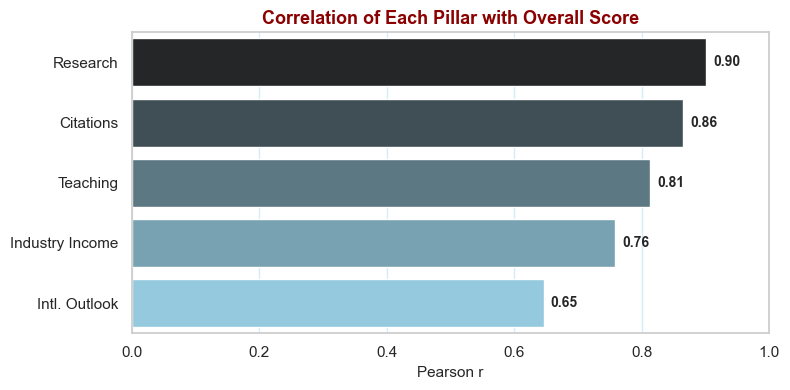

In [68]:
plt.figure(figsize=(8, 4))

ax = sns.barplot(
    x=corr.values,
    y=[PRETTY[c] for c in corr.index],
    hue=corr.index,color=THEME_COLORS["primary"],
    legend=False
)

plt.title("Correlation of Each Pillar with Overall Score", fontsize=13, weight="bold")
plt.xlabel("Pearson r")
plt.xlim(0, 1)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=5,
        fontsize=10,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

**Research (r = 0.90) is the single strongest predictor**, followed by Citations (0.86) and Teaching (0.81). International Outlook is the weakest (0.65).

The takeaway for an institution trying to climb: research volume and reputation carry the most weight, and they're also the slowest and most expensive to build.

## 5. The full correlation picture

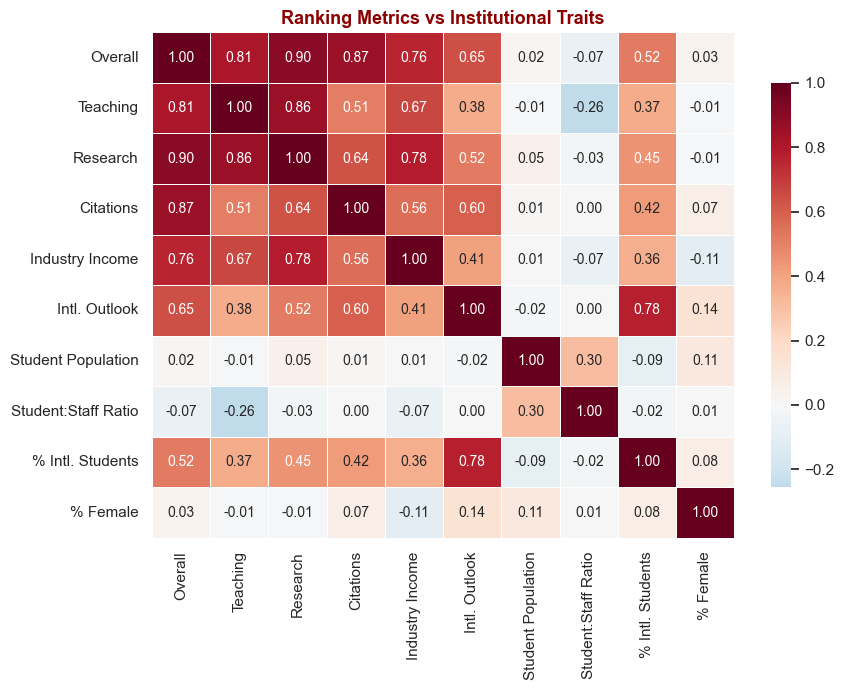

In [71]:
cols = ["scores_overall_num", *SCORE_COLS, "students",
        "student_staff_ratio", "pc_intl_students", "pc_female"]
cm = df[cols].corr()
cm.index = [PRETTY.get(c, c) for c in cm.index]
cm.columns = [PRETTY.get(c, c) for c in cm.columns]

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Ranking Metrics vs Institutional Traits", fontsize=13, weight="bold")
plt.tight_layout(); plt.show()

## 6. Testing the student-to-staff ratio assumption

Small classes are conventionally treated as a proxy for teaching quality. Does the data support that?

r = -0.076


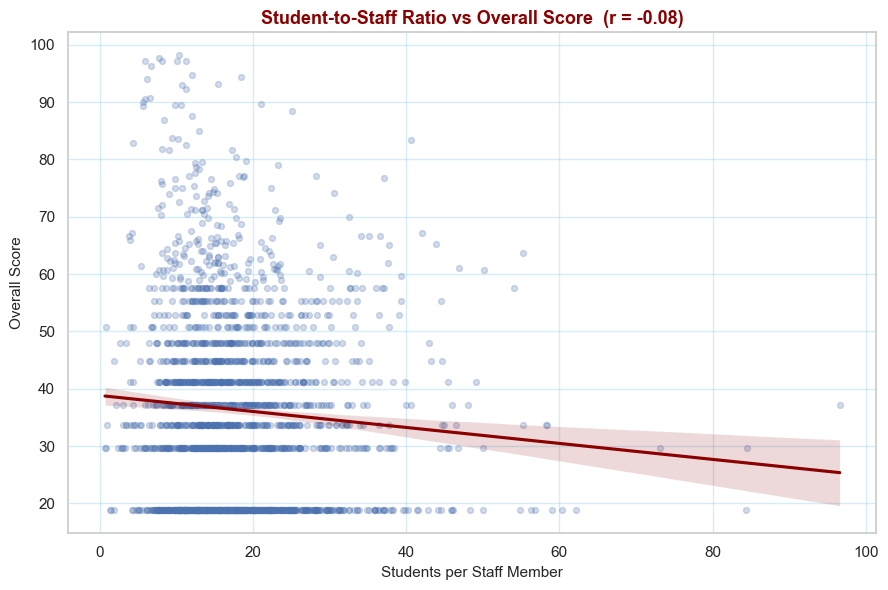

In [73]:
sub = df.dropna(subset=["student_staff_ratio", "scores_overall_num"])
sub = sub[sub["student_staff_ratio"] < 100]   # trim a few extreme outliers (max 226)

r = sub["student_staff_ratio"].corr(sub["scores_overall_num"])
print(f"r = {r:.3f}")

plt.figure(figsize=(9, 6))
sns.regplot(data=sub, x="student_staff_ratio", y="scores_overall_num",
            scatter_kws={"alpha": 0.25, "s": 18}, line_kws={"color": THEME_COLORS["secondary"]})
plt.title(f"Student-to-Staff Ratio vs Overall Score  (r = {r:.2f})",
          fontsize=13, weight="bold")
plt.xlabel("Students per Staff Member"); plt.ylabel("Overall Score")
plt.tight_layout(); plt.show()

In [50]:
print("Institution size vs score: r =", round(df["students"].corr(df["scores_overall_num"]), 3))
print("% intl students vs score: r =", round(df["pc_intl_students"].corr(df["scores_overall_num"]), 3))

Institution size vs score: r = 0.022
% intl students vs score: r = 0.515


**The ratio is essentially uncorrelated with Score (r = −0.076).**  Although, the plot can somewhat convey that increasing students per staff member affects the overall score slightly.

But **internationalization is the moderate institutional-trait predictor (r = 0.52)** — and unlike a research portfolio, student diversity is something an institution can shift within a few admissions cycles.

## 7. Top 100 vs everyone else

If the top 100 are different, *how* are they different?

In [51]:
gap = elite_vs_rest(df, n_elite=100)
gap

,Top 100,Rest,Gap
scores_teaching,69.15,27.01,42.14
scores_research,72.49,20.57,51.92
scores_citations,90.47,51.56,38.91
scores_industry_income,90.40,46.41,43.99
scores_international_outlook,79.12,48.43,30.69
student_staff_ratio,15.00,18.41,-3.41
pc_intl_students,29.85,10.23,19.62


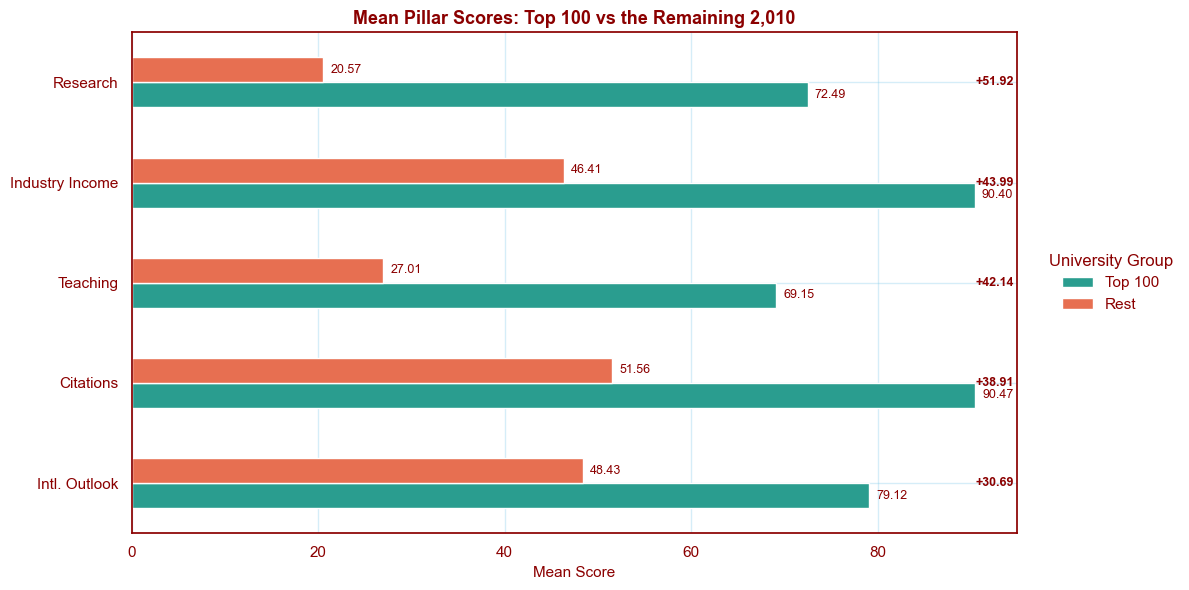

In [52]:
g = gap.drop(index=["student_staff_ratio", "pc_intl_students"]).sort_values("Gap")
g.index = [PRETTY[i] for i in g.index]

ax = g[["Top 100", "Rest"]].plot(kind="barh", figsize=(12, 6), color=["#2a9d8f", "#e76f51"])
plt.title("Mean Pillar Scores: Top 100 vs the Remaining 2,010", fontsize=13, weight="bold")
plt.xlabel("Mean Score")
plt.ylabel("")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=5, fontsize=9)
ax.legend(
    title="University Group",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5), frameon=False)

differences = g["Top 100"] - g["Rest"]

x_right = g[["Top 100", "Rest"]].max().max() *1

for i, diff in enumerate(differences):
    ax.text(x_right, i, f"{diff:+.2f}", va="center", ha="left", fontsize=9, fontweight="bold")
plt.tight_layout()
plt.show()

**Research shows the widest gap (+51.9 points)** — more than any other pillar. Elite status is, above all, a research phenomenon.

International Outlook shows the *narrowest* gap (+30.7), which cuts both ways: it's the pillar where non-elite institutions are closest to competitive, and therefore where marginal effort is best spent.

## 8. Pillar distributions

C:\Users\gvedi\AppData\Local\Temp\ipykernel_26500\3562323774.py:5: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#87CEEB'` for the same effect.

  sns.boxplot(data=long, x="Score", y="Pillar", hue="Pillar",


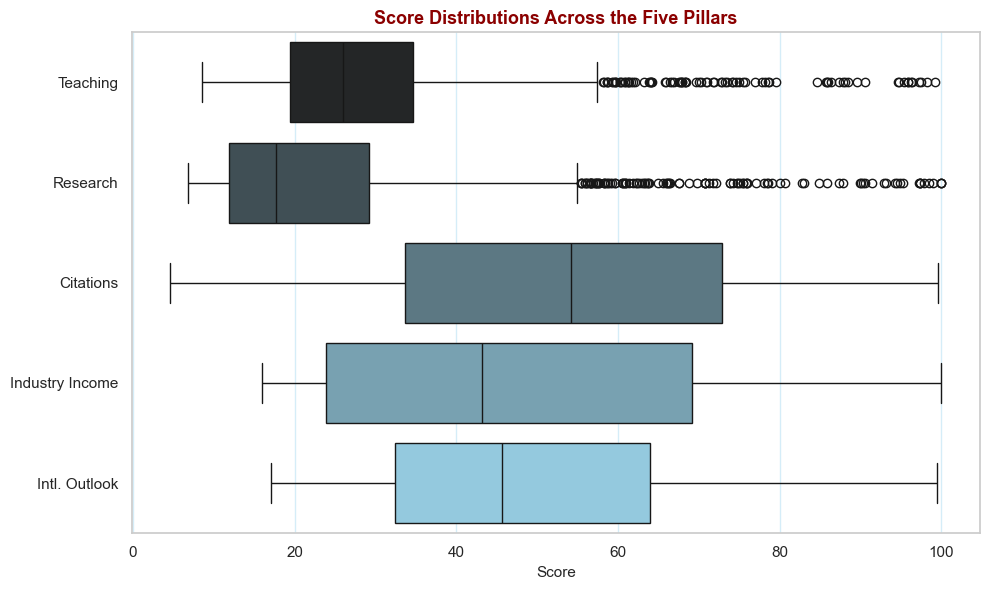

In [76]:
long = df[SCORE_COLS].melt(var_name="Pillar", value_name="Score")
long["Pillar"] = long["Pillar"].map(PRETTY)

plt.figure(figsize=(10, 6))
sns.boxplot(data=long, x="Score", y="Pillar", hue="Pillar",
         color=THEME_COLORS["primary"], legend=False)
plt.title("Score Distributions Across the Five Pillars", fontsize=13, weight="bold")
plt.ylabel(""); plt.tight_layout(); plt.show()

## 9. Country-level analysis

### Volume: who has the most ranked universities?

C:\Users\gvedi\AppData\Local\Temp\ipykernel_26500\3228435119.py:5: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#87CEEB'` for the same effect.

  ax = sns.barplot(x=counts.values, y=counts.index, hue=counts.index, color=THEME_COLORS["primary"], legend=False)


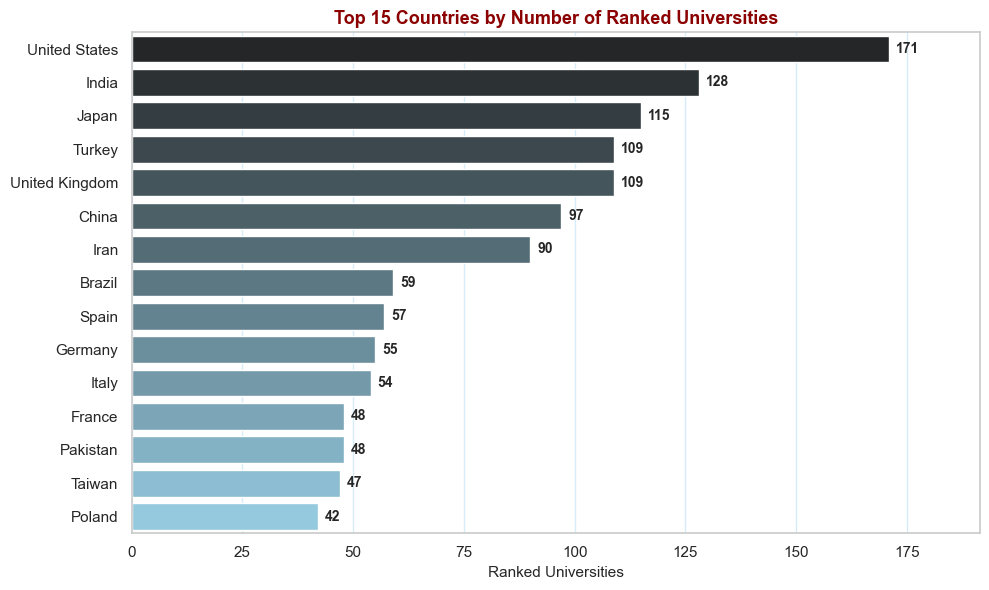

In [77]:
counts = df["country"].value_counts().head(15)

plt.figure(figsize=(10, 6))

ax = sns.barplot(x=counts.values, y=counts.index, hue=counts.index, color=THEME_COLORS["primary"], legend=False)

plt.title("Top 15 Countries by Number of Ranked Universities",
    fontsize=13,weight="bold")

plt.xlabel("Ranked Universities")
plt.ylabel("")

for container in ax.containers:
    ax.bar_label( container, fmt="%.0f",
        padding=5, fontsize=10, fontweight="bold")

plt.xlim(0, counts.max() * 1.12)

plt.tight_layout()
plt.show()


### Quality: who has the *best* ranked universities?

Restricted to countries with at least 10 ranked institutions, so a country with two strong universities doesn't top the table.

In [55]:
cs = country_summary(df, min_universities=10)
cs.head(15)

,universities,mean_overall,mean_teaching,mean_research,mean_citations,mean_industry,mean_intl
country,,,,,,,
Netherlands,12,65.23,46.12,53.68,85.78,91.60,88.61
Switzerland,12,57.14,45.27,40.48,75.33,78.19,88.85
Belgium,10,56.14,38.73,44.89,75.89,86.96,74.70
Australia,37,55.48,33.13,37.61,84.76,74.05,85.46
Sweden,13,55.06,36.57,41.92,80.43,76.38,70.03
Germany,55,54.52,41.36,41.93,73.43,81.86,66.25
United States,171,53.17,44.86,38.49,72.61,70.55,57.83
Austria,13,50.49,38.31,32.78,67.57,78.13,85.64
Canada,34,49.07,33.23,36.44,68.61,71.94,75.89


C:\Users\gvedi\AppData\Local\Temp\ipykernel_26500\162885451.py:4: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#87CEEB'` for the same effect.

  ax = sns.barplot(x=top15["mean_overall"], y=top15.index,


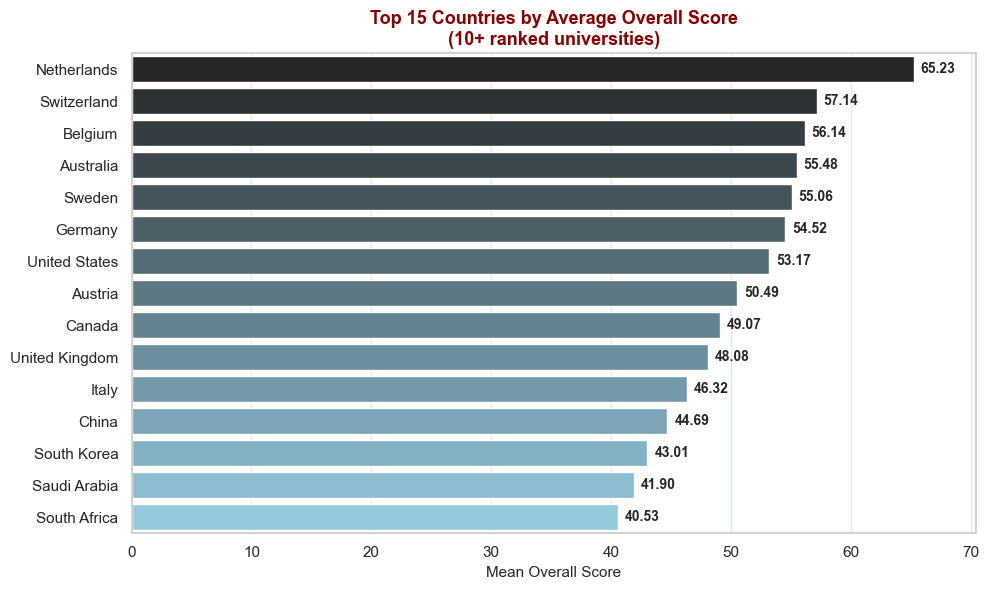

In [78]:
top15 = cs.head(15)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=top15["mean_overall"], y=top15.index,
    hue=top15.index, color=THEME_COLORS["primary"], legend=False)

plt.title(
    "Top 15 Countries by Average Overall Score\n(10+ ranked universities)",
    fontsize=13, weight="bold")

plt.xlabel("Mean Overall Score")
plt.ylabel("")

for container in ax.containers:
    ax.bar_label( container, fmt="%.2f", padding=5, fontsize=10, fontweight="bold")

plt.xlim(0, top15["mean_overall"].max() * 1.08)

plt.tight_layout()
plt.show()

**Volume and quality decouple sharply.**

The US has 171 ranked universities but ranks **seventh** on average score (53.2). The UK has 109 and ranks **tenth** (48.1). The leaders are small, research-dense systems: the **Netherlands (65.2)**, Switzerland (57.1), and Belgium (56.1).

This is a scale effect: large systems rank many mid-tier institutions alongside their flagships, which drags the average down. It's not a weakness — but it does mean "number of ranked universities" is a poor proxy for system quality.

### Volume vs quality, plotted

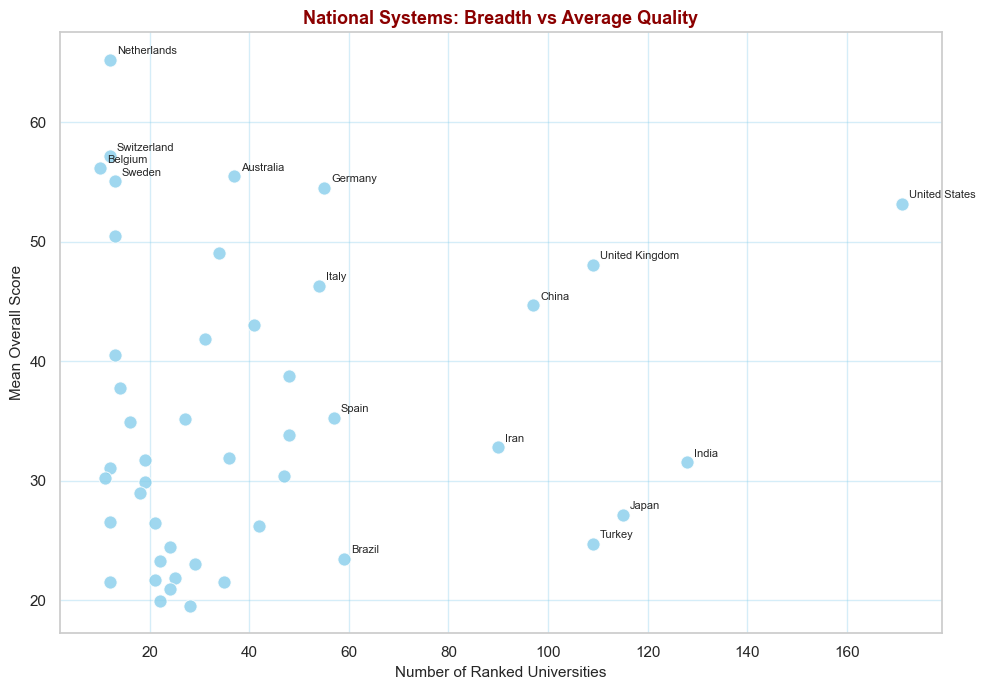

In [79]:
plt.figure(figsize=(10, 7))
sns.scatterplot(data=cs, x="universities", y="mean_overall", s=90,
                color=THEME_COLORS["primary"], alpha=0.8)
for name, row in cs.iterrows():
    if row["universities"] > 50 or row["mean_overall"] > 52:
        plt.annotate(name, (row["universities"], row["mean_overall"]),
                     fontsize=8, xytext=(5, 4), textcoords="offset points")
plt.title("National Systems: Breadth vs Average Quality", fontsize=13, weight="bold")
plt.xlabel("Number of Ranked Universities"); plt.ylabel("Mean Overall Score")
plt.tight_layout(); plt.show()

## 10. Top 20 universities

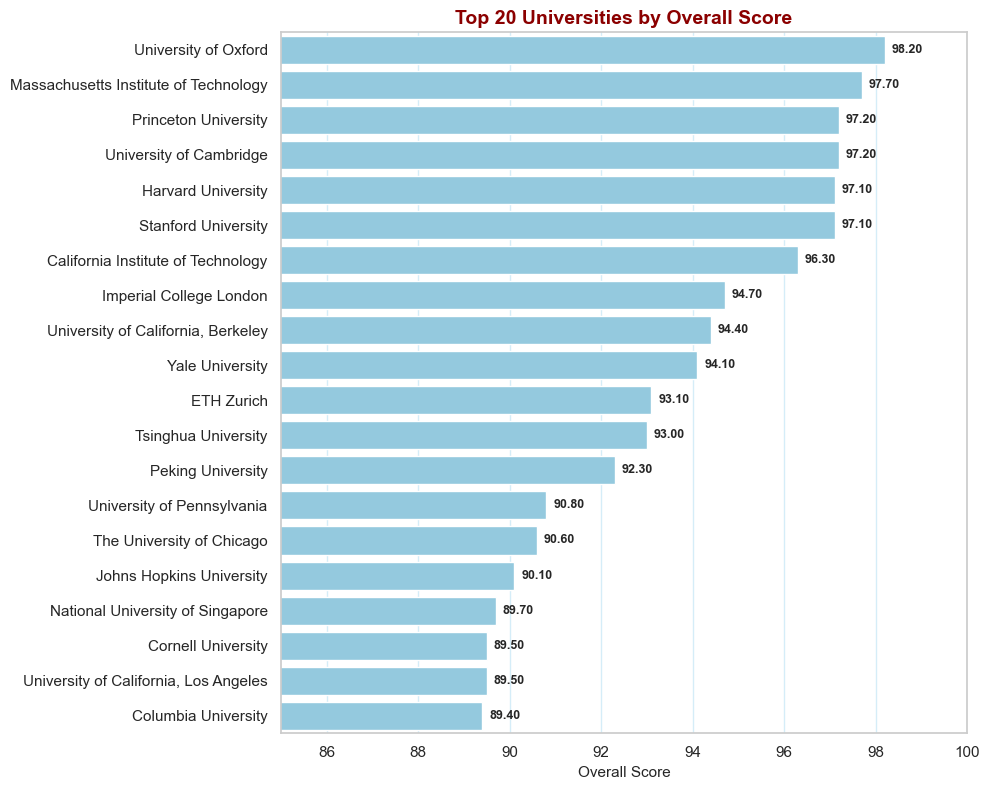

In [80]:
top20 = df.nsmallest(20, "rank_num")

plt.figure(figsize=(10, 8))

ax = sns.barplot(data=top20, y="university", x="scores_overall_num",
    color=THEME_COLORS["primary"],legend=False)

plt.title("Top 20 Universities by Overall Score", fontsize=14, weight="bold")

plt.xlabel("Overall Score")
plt.ylabel("")
plt.xlim(85, 100)

# Add score values
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f",
        padding=5, fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()


## 11. Conclusions

1. **Research is the dominant driver of rank** (r = 0.90), and shows the largest top-100 vs rest gap (+51.9 points). Elite status is fundamentally a research phenomenon.

2. **Internalization** correlates elite status, not complete causes of it.

3. **Internationalization is the most actionable differentiator** (r = 0.52) — the strongest institutional trait in the data, and the one most responsive to short-term policy.

4. **Breadth and quality decouple at the national level.** The US and UK lead on count but sit seventh and tenth on average score, behind the Netherlands, Switzerland, and Belgium.

5. **Pillars aren't equally discriminating.** Citations and Industry Income are broadly distributed and separate institutions poorly; Research and Teaching are compressed at the bottom with long elite tails.

